In [1]:
from utils import make_chirp
import config
import numpy as np
from scipy.signal import find_peaks, correlate
import matplotlib.pyplot as plt

Found chirps at: [ 4009  9033 14057 19081 24105 29129 34153 39177 44201 49225]
Expected start:  [ 4000  9024 14048 19072 24096 29120 34144 39168 44192 49216]


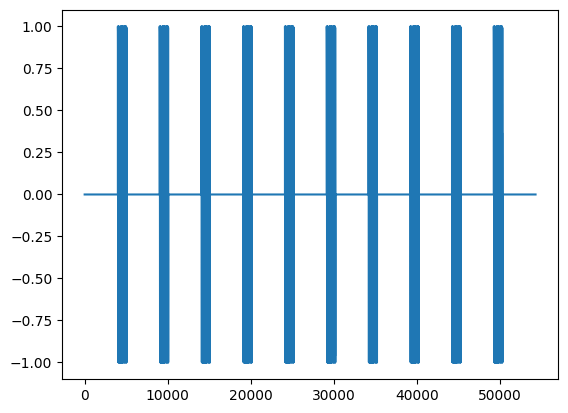

In [ ]:
from scipy.signal import find_peaks

def find_chirp_in_signal(signal, num_chirps=None):
    """
    Find chirp locations in signal using cross-correlation and peak detection.
    
    Args:
        signal: Input signal to search
        num_chirps: Expected number of chirps (optional). If provided, returns only top N peaks.
    
    Returns:
        Sorted array of chirp start indices
    """
    reference_chirp = make_chirp(config.CHIRP_LOW, config.CHIRP_HIGH, config.CHIRP_SAMPLES)
    
    # Cross-correlation (gives correlation for each lag)
    correlation = np.correlate(signal, reference_chirp, mode='valid')
    #plt.plot(correlation)
    # Much stricter threshold and find peaks
    threshold = np.max(correlation) * 0.7
    peaks, properties = find_peaks(correlation, height=threshold, distance=config.CHIRP_SAMPLES*1.5)
    
    # Sort by correlation magnitude (descending)
    peak_indices = peaks[np.argsort(properties['peak_heights'])[::-1]]
    
    # If expected number given, keep only top N
    if num_chirps is not None:
        peak_indices = peak_indices[:num_chirps]
    
    # Convert correlation indices to signal indices
    # With 'valid' mode: peak_idx in correlation = chirp_start in signal
    chirp_starts = np.sort(peak_indices)
    
    return chirp_starts


# Test it
guard = np.random.normal(0,0, config.CHIRP_SPACING)
chirps = [guard]
for i in range(10):
    chirps.append(make_chirp(config.CHIRP_LOW, config.CHIRP_HIGH, config.CHIRP_SAMPLES)) #+ np.random.normal(0,0.01,config.CHIRP_SAMPLES))
    chirps.append(guard)



signal = np.concatenate(chirps)

channel = np.random.normal(0, 1, 30)
recv = np.convolve(signal, channel)

chirp_starts = find_chirp_in_signal(recv[:signal.size], num_chirps=10)
expected_start =  np.arange(0,10,1)*(config.CHIRP_SAMPLES + config.CHIRP_SPACING) + config.CHIRP_SPACING

plt.plot(signal, label='signal')
#plt.plot(recv, label='received_chirps')
#plt.legend()
#plt.show()

print("Found chirps at:", chirp_starts)
print("Expected start: ", expected_start)

In [3]:
def estimte_symbol_offset(chirp_starts: np.ndarray):
    """
    Given the observed locations of the chirp peaks can estimate symbol time offset

    Args:
        chirp_starts (np.ndarray): location of chirp
        signal (np.ndarray): received signal
    """
    chirp_spacing = config.CHIRP_SPACING + config.CHIRP_SAMPLES # Distance between start of 2 chirps
    measured_spacing = np.diff(chirp_starts)
    
    sto_offset = np.mean(measured_spacing - chirp_spacing)
    return sto_offset

print(estimte_symbol_offset(chirp_starts))

0.0


/home/arnav/Desktop/Projects/GF3/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/arnav/Desktop/Projects/GF3/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


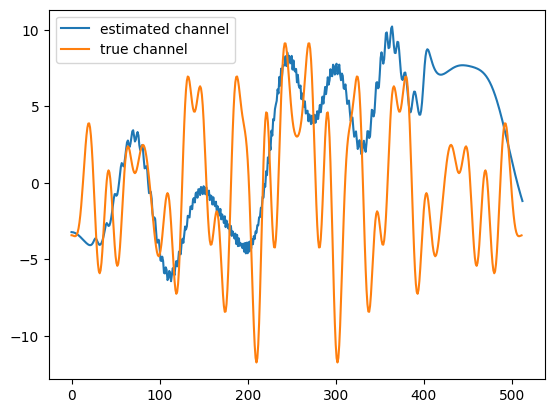

In [4]:
def _remove_linear_phase(h_freq: np.ndarray) -> np.ndarray:
    phase = np.unwrap(np.angle(h_freq))
    freqs = np.arange(len(phase))
    slope = np.polyfit(freqs, phase, 1)[0]
    return h_freq * np.exp(-1j * slope * freqs)


def channel_estimation(chirp_starts: np.ndarray, signal: np.ndarray):
    reference_chirp = make_chirp(config.CHIRP_LOW, config.CHIRP_HIGH, config.CHIRP_SAMPLES)
    true_chirp_freq = np.fft.rfft(reference_chirp)
    chirp_estimates = []

    for start in chirp_starts:
        end = start + config.CHIRP_SAMPLES
        if start < 0 or end > len(signal):
            continue

        received_chirp = signal[start:end]
        received_freq = np.fft.rfft(received_chirp)

        # Simple chirp-based channel estimate per chirp
        H_freq = received_freq / true_chirp_freq
        H_freq = _remove_linear_phase(H_freq)
        chirp_estimates.append(H_freq)

    if len(chirp_estimates) == 0:
        raise ValueError("No valid chirp segments for channel estimation")

    G_freq = np.mean(chirp_estimates, axis=0)
    g_time = np.fft.irfft(G_freq, n=config.CHIRP_SAMPLES)

    return g_time, G_freq


est_channel_time, f = channel_estimation(chirp_starts, recv)
plt.plot(f, label='estimated channel')
plt.plot(np.fft.fft(channel, 512), label='true channel')
plt.legend()
